Problem Statement - HELP International CEO needs to strategically focus on the countries in dire need of aid. We need to classify them using Hierarchical and give a final list of countries that must be provided aid using the dataset provided

Analysis approach - check the data, conduct null removal/imputation if necessary. Conduct univariate/bivariate analysis and outlier analysis as well. I would not prefer to remove outliers since the countries in direst need of aid would usually have significant outliers in terms of socio-economic variables.
First i would select the ideal value of k and then run the model. Using using single and complete linkages and using silhoutte score i would be selecting the ideal value of k. After identifying the clusters, i would be able to run analysis on the clusters provided and give a final list of countries that would be in direst need of aid.

In [234]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [235]:
# Importing  required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [236]:
# Loading the dataset

df = pd.read_csv("Country-data.csv")

In [237]:
# Having a look at the first 10 rows

df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [238]:
# Checking the number of rows and columns

df.shape

(167, 10)

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


Since the above information shows that there are not null values, we would not be checking these further

In [240]:
# Checking the column names as a list

df.columns.to_list()

['country',
 'child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

In [241]:
# Column wise description of dataset

df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Now we would be performing univariate analysis using histplots

In [242]:
column_without_country = ['child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

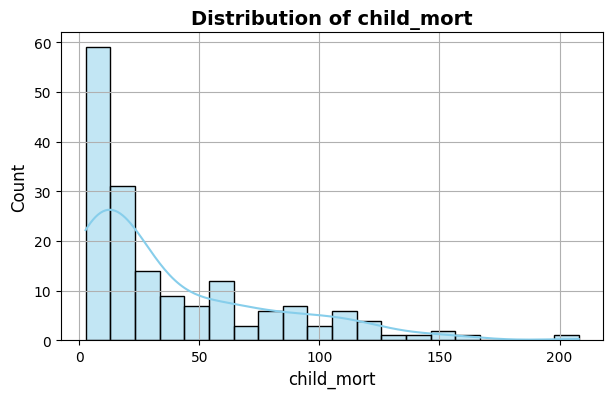

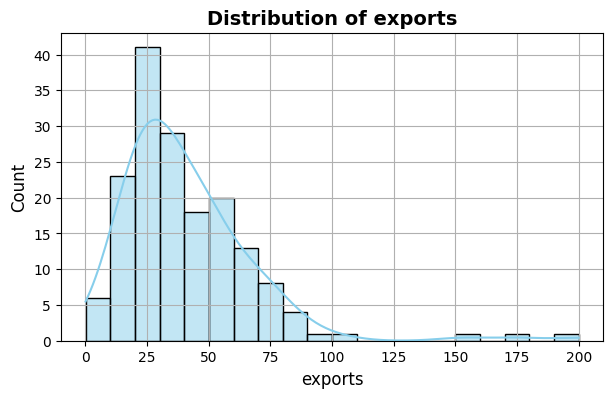

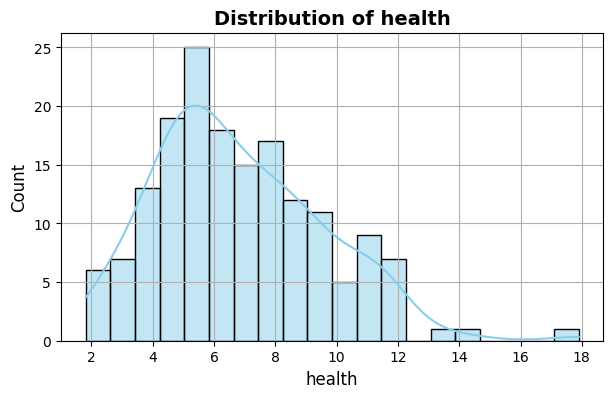

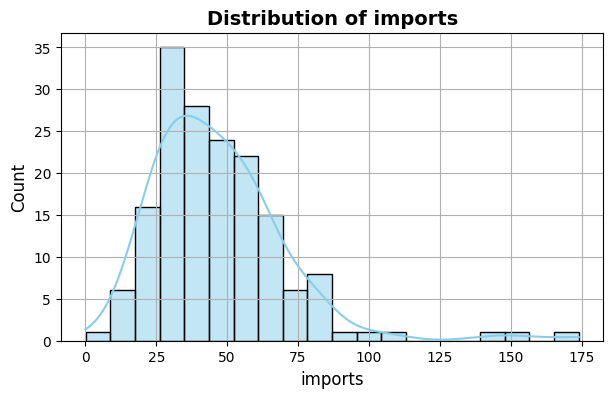

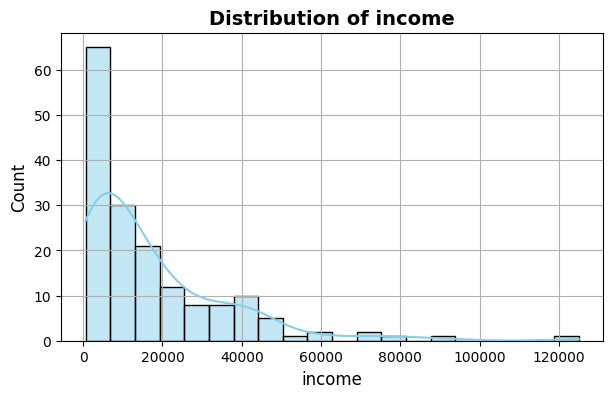

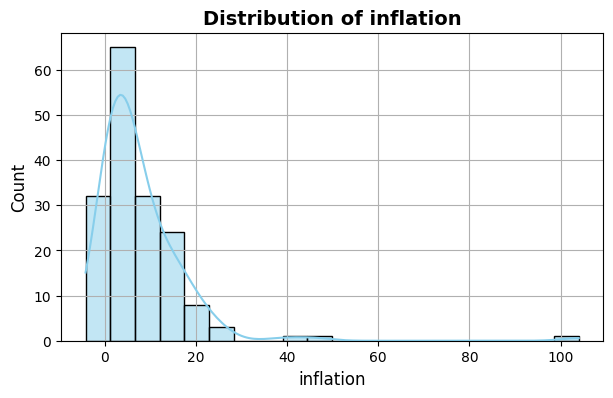

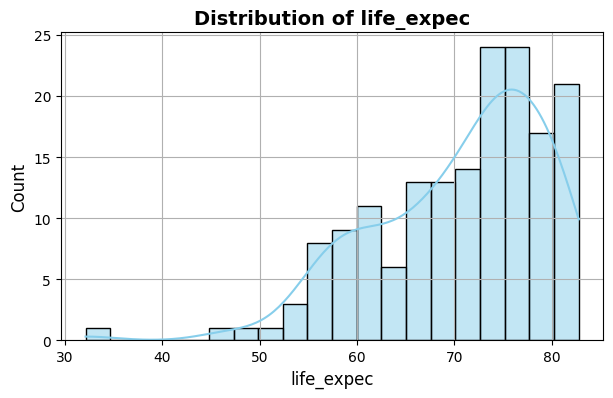

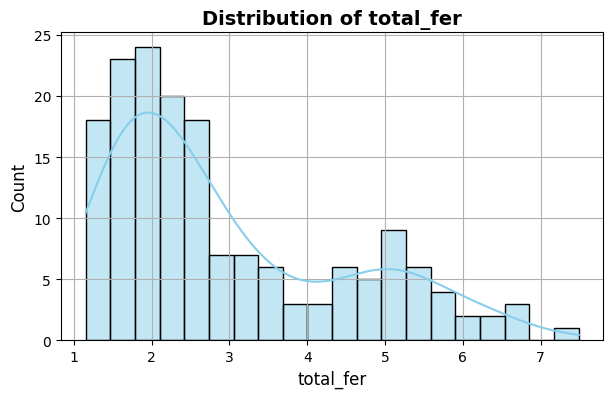

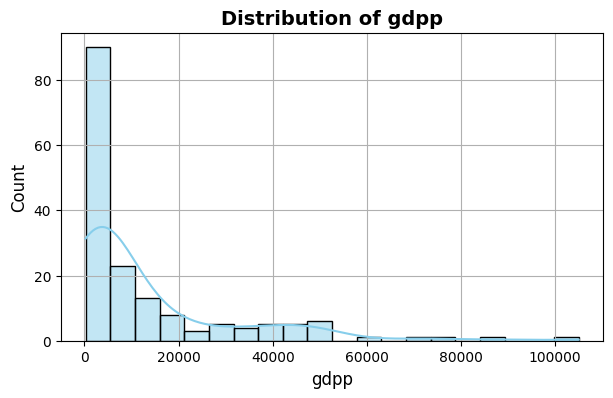

In [243]:
# Plotting histplot for various columns

for col in column_without_country:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, bins=20, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid()
    plt.show()

<Axes: >

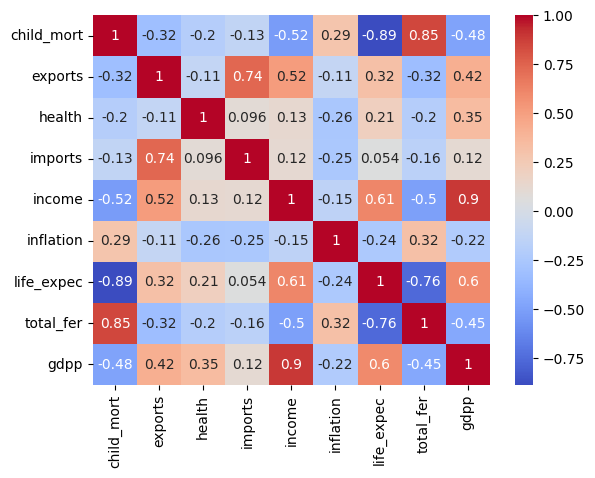

In [244]:
# we use heatmap to check correlation and multicollinearity

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap = 'coolwarm')

Above analysis shows some serious multicollinearity. We should drop some columns

In [245]:
col_to_drop = ['total_fer', 'income', 'life_expec']
df.drop(columns=col_to_drop, inplace=True)

In [246]:
df.columns.to_list()

['country', 'child_mort', 'exports', 'health', 'imports', 'inflation', 'gdpp']

<Axes: >

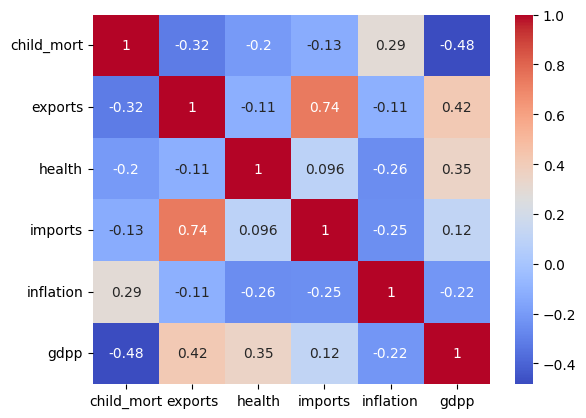

In [247]:
# now we run the heatmap again to see if there is a multicollinearity issue

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

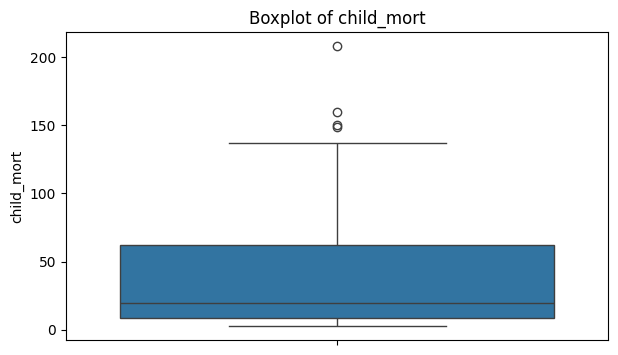

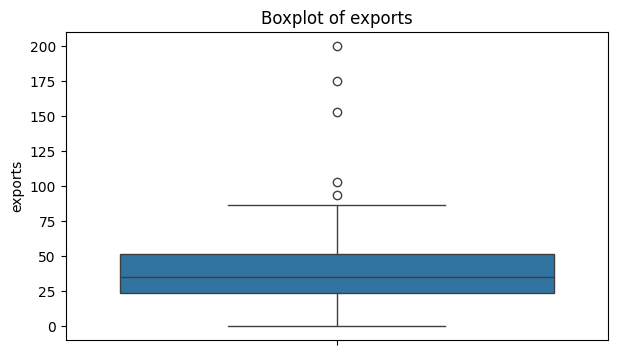

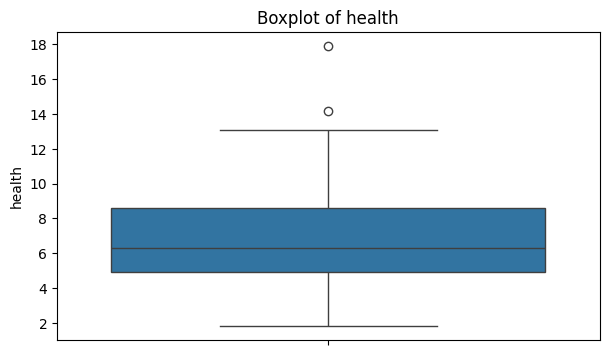

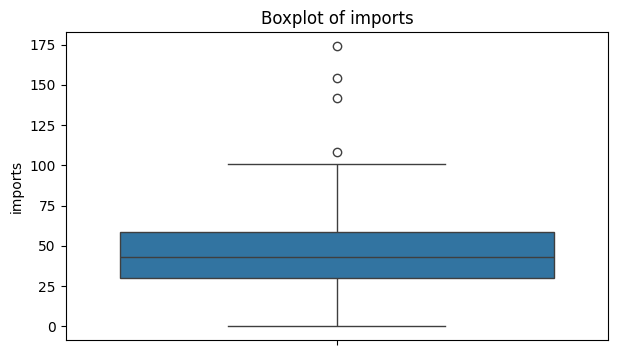

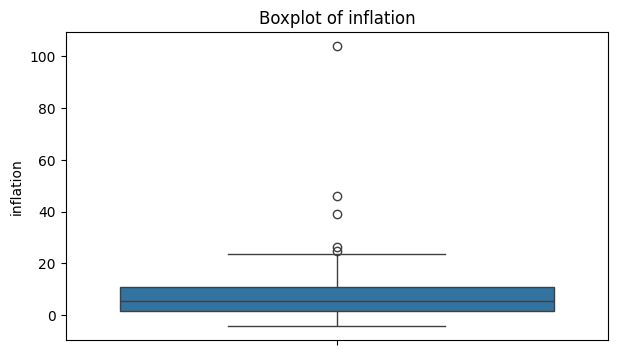

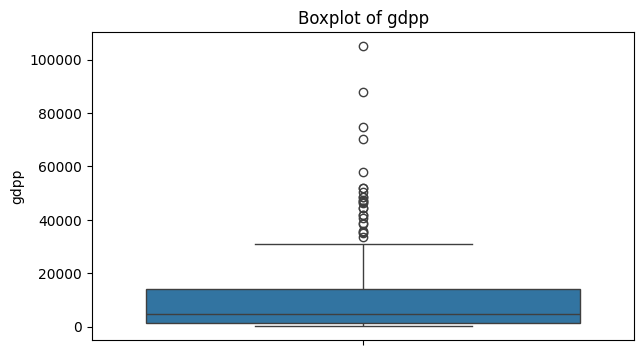

In [248]:
# performing outlier analysis using boxplots

columns_wo_country = ['child_mort', 'exports', 'health', 'imports', 'inflation', 'gdpp']

for col in columns_wo_country:
  plt.figure(figsize=(7, 4))
  sns.boxplot(data = df, y = col)
  plt.title(f'Boxplot of {col}')
  plt.show()

After not removing the outliers, the clustering results are terrible. So i would be removing the above 80 quantile of gdpp since those countries are already rich and wont be in any need for aid.

In [249]:
gdpp_80 = df['gdpp'].quantile(0.80)

In [250]:
gdpp_80

np.float64(21020.000000000004)

In [251]:
df = df[(df['gdpp'] <= 21020) & (df['child_mort'] >= 10)]

In [252]:
df.describe()

,child_mort,exports,health,imports,inflation,gdpp
count,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000
mean,51.847458,34.630500,6.121864,44.549711,9.792076,4113.677966
std,40.884720,18.724868,2.358481,19.617127,11.726932,4179.957267
min,10.000000,0.109000,1.970000,0.065900,-4.210000,231.000000
25%,18.650000,21.525000,4.562500,29.675000,3.590000,972.250000
50%,36.600000,30.150000,5.670000,43.000000,6.975000,2910.000000
75%,78.350000,47.000000,7.075000,57.250000,13.700000,5742.500000
max,208.000000,93.800000,14.200000,108.000000,104.000000,19300.000000


In [253]:
# Removing the categorical variable 'country' for scaling purposes

df_clustering = df.drop('country', axis = 1)
df_clustering

,child_mort,exports,health,imports,inflation,gdpp
0,90.2,10.0,7.58,44.9,9.44,553
1,16.6,28.0,6.55,48.6,4.49,4090
2,27.3,38.4,4.17,31.4,16.10,4460
3,119.0,62.3,2.85,42.9,22.40,3530
4,10.3,45.5,6.03,58.9,1.44,12200
...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2.62,2970
163,17.1,28.5,4.91,17.6,45.90,13500
164,23.3,72.0,6.84,80.2,12.10,1310
165,56.3,30.0,5.18,34.4,23.60,1310


In [254]:
# instantiating and implementing standard scaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

In [255]:
# we import below modules to run hierarchical clustering

from scipy.cluster.hierarchy import linkage, dendrogram

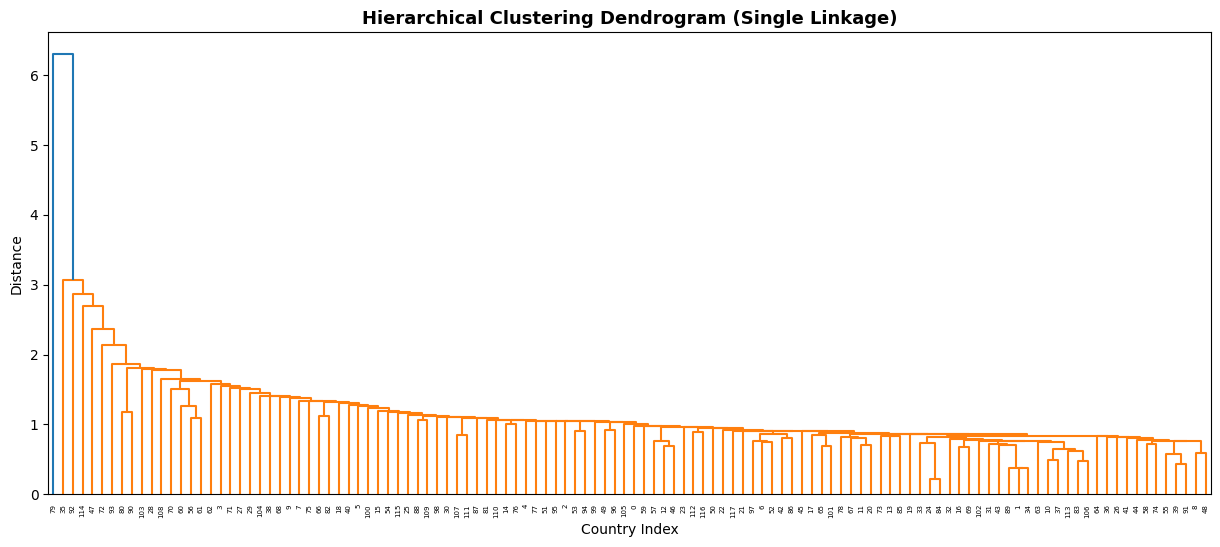

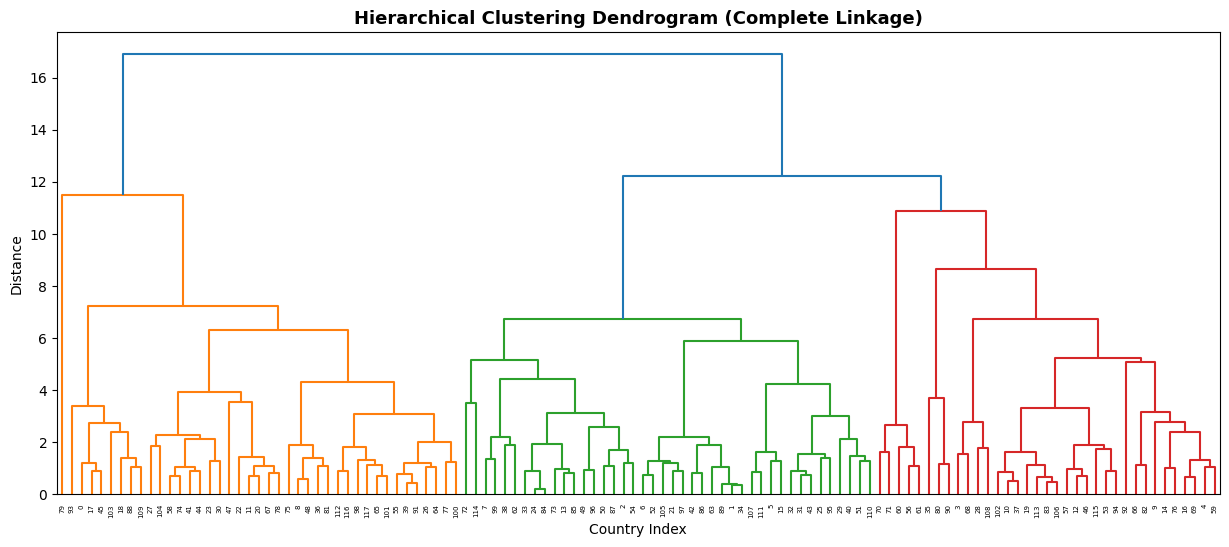

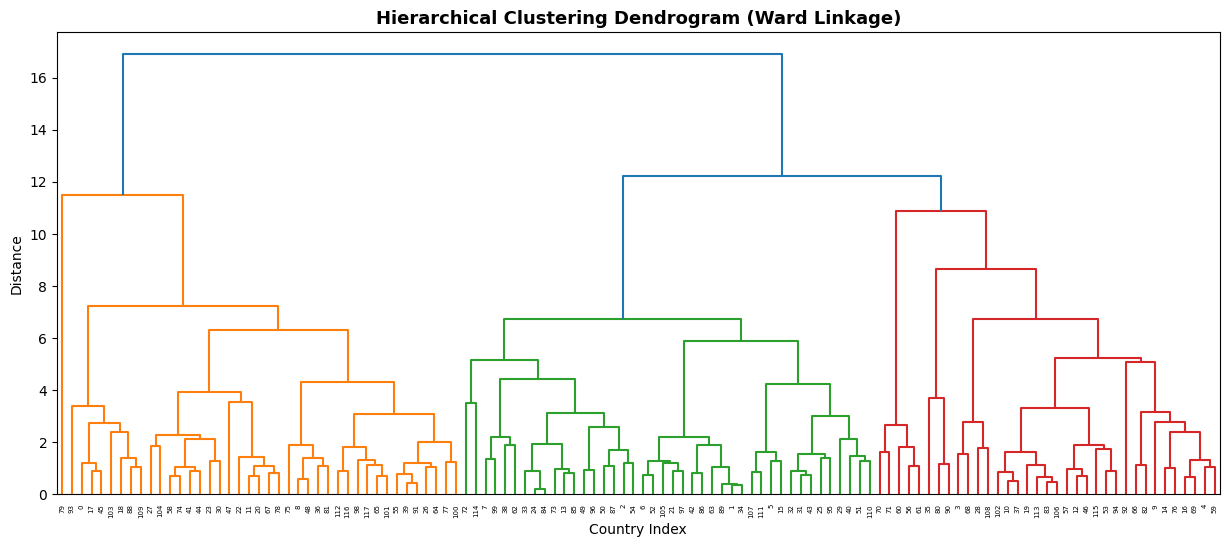

In [256]:
mergings_single = linkage(df_scaled, method='single')
mergings_complete = linkage(df_scaled, method='complete')
mergings_complete = linkage(df_scaled, method='ward')

plt.figure(figsize=(15, 6))
dendrogram(mergings_single)
plt.title('Hierarchical Clustering Dendrogram (Single Linkage)', fontsize=13, fontweight='bold')
plt.xlabel('Country Index')
plt.ylabel('Distance')
plt.show()

plt.figure(figsize=(15, 6))
dendrogram(mergings_complete)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)', fontsize=13, fontweight='bold')
plt.xlabel('Country Index')
plt.ylabel('Distance')
plt.show()

plt.figure(figsize=(15, 6))
dendrogram(mergings_complete)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold')
plt.xlabel('Country Index')
plt.ylabel('Distance')
plt.show()

In [257]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Range of cluster cuts to test
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    # Instantiate Hierarchical clustering using single linkage
    hcs = AgglomerativeClustering(n_clusters=num_clusters, linkage='single')
    hcs_labels = hcs.fit_predict(df_scaled)

    # Calculate the silhouette score
    silhouette_avg = silhouette_score(df_scaled, hcs_labels)

    # Print the results
    print(f"For n_clusters={num_clusters}, the hierarchical silhouette score is {silhouette_avg:.2f}")

For n_clusters=2, the hierarchical silhouette score is 0.64
For n_clusters=3, the hierarchical silhouette score is 0.40
For n_clusters=4, the hierarchical silhouette score is 0.37
For n_clusters=5, the hierarchical silhouette score is 0.30
For n_clusters=6, the hierarchical silhouette score is 0.21
For n_clusters=7, the hierarchical silhouette score is 0.11
For n_clusters=8, the hierarchical silhouette score is 0.10


In [258]:
# Range of cluster cuts to test
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    # Instantiate Hierarchical clustering using complete linkage
    hcc = AgglomerativeClustering(n_clusters=num_clusters, linkage='complete')
    hcc_labels = hcc.fit_predict(df_scaled)

    # Calculate the silhouette score
    silhouette_avg = silhouette_score(df_scaled, hcc_labels)

    # Print the results
    print(f"For n_clusters={num_clusters}, the hierarchical silhouette score is {silhouette_avg:.2f}")

For n_clusters=2, the hierarchical silhouette score is 0.64
For n_clusters=3, the hierarchical silhouette score is 0.28
For n_clusters=4, the hierarchical silhouette score is 0.25
For n_clusters=5, the hierarchical silhouette score is 0.19
For n_clusters=6, the hierarchical silhouette score is 0.16
For n_clusters=7, the hierarchical silhouette score is 0.16
For n_clusters=8, the hierarchical silhouette score is 0.18


In [259]:
# Range of cluster cuts to test
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    # Instantiate Hierarchical clustering using wward linkage
    hcw = AgglomerativeClustering(n_clusters=num_clusters, linkage='ward')
    hcw_labels = hcw.fit_predict(df_scaled)

    # Calculate the silhouette score
    silhouette_avg = silhouette_score(df_scaled, hcw_labels)

    # Print the results
    print(f"For n_clusters={num_clusters}, the hierarchical silhouette score is {silhouette_avg:.2f}")

For n_clusters=2, the hierarchical silhouette score is 0.21
For n_clusters=3, the hierarchical silhouette score is 0.17
For n_clusters=4, the hierarchical silhouette score is 0.18
For n_clusters=5, the hierarchical silhouette score is 0.21
For n_clusters=6, the hierarchical silhouette score is 0.22
For n_clusters=7, the hierarchical silhouette score is 0.20
For n_clusters=8, the hierarchical silhouette score is 0.20


While ward clustering is not a part of the assingment, had no choice but to use it since the other 2 methods were not giving correct results

In [260]:

# Instantiate the final chosen model - Ward clustering
final_hcw = AgglomerativeClustering(n_clusters=3, linkage='ward')
final_labels = final_hcw.fit_predict(df_scaled)

# Assign back to your primary dataframe for profiling
df['final_cluster_id'] = final_labels

# countries in each of the 3 groups
print(df['final_cluster_id'].value_counts())


final_cluster_id
2    42
0    41
1    35
Name: count, dtype: int64


In [261]:
# Inspect the 3 countries isolated in Cluster 2
df[df['final_cluster_id'] == 2][['country', 'gdpp', 'child_mort']]

,country,gdpp,child_mort
1,Albania,4090,16.6
2,Algeria,4460,27.3
5,Argentina,10300,14.5
6,Armenia,3220,18.1
9,Azerbaijan,5840,39.2
19,Bolivia,1980,46.6
22,Brazil,11200,19.8
30,Cape Verde,3310,26.5
34,China,4560,15.7
35,Colombia,6250,18.6


In [262]:
# Inspect the 3 countries isolated in Cluster 1
df[df['final_cluster_id'] == 1][['country', 'gdpp', 'child_mort']].head(10)

,country,gdpp,child_mort
3,Angola,3530,119.0
4,Antigua and Barbuda,12200,10.3
13,Barbados,16000,14.2
16,Belize,4340,18.8
18,Bhutan,2180,42.7
21,Botswana,6350,52.5
24,Bulgaria,6840,10.8
27,Cambodia,786,44.4
38,"Congo, Rep.",2740,63.9
49,Equatorial Guinea,17100,111.0


In [263]:
# Inspect the 3 countries isolated in Cluster 1
df[df['final_cluster_id'] == 0][['country', 'gdpp', 'child_mort']].head(10)

,country,gdpp,child_mort
0,Afghanistan,553,90.2
12,Bangladesh,758,49.4
17,Benin,758,111.0
25,Burkina Faso,575,116.0
26,Burundi,231,93.6
28,Cameroon,1310,108.0
31,Central African Republic,446,149.0
32,Chad,897,150.0
36,Comoros,769,88.2
37,"Congo, Dem. Rep.",334,116.0


Above code shows that cluster 0 has the required list of countries in need of maximum aid.

In [264]:
df[df['final_cluster_id'] == 0]['country'].head(5).to_list()

['Afghanistan', 'Bangladesh', 'Benin', 'Burkina Faso', 'Burundi']

Above 5 are the countries that the CEO of the help international needs to focus on the most.